# Examples of custom pipeline uses

Examples of OHLCV data manipulation using custom pipelines.

In [1]:
import re

import numpy as np
import pandas as pd
from eccore.ipython import nb_setup, pandas_nrows_ncols
from nbdev.showdoc import show_doc
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import FeatureUnion, Pipeline
from sklearn.preprocessing import MinMaxScaler, StandardScaler

from myquantlab.core import load_test_df
from myquantlab.pipeline import (EMATransformer, MATransformer,
                                 ReturnTransformer, StdTransformer,
                                 simplify_colnames, dframe)

nb_setup()

Set autoreload mode


# Apply customer transforms to OHLCV data

In [2]:
df = load_test_df()
df.head(3)

,Open,High,Low,Close,Volume
dt,,,,,
2018-10-22,2759.02,2779.27,2747.27,2754.48,26562
2018-10-23,2753.11,2755.36,2690.69,2743.45,38777
2018-10-24,2744.83,2748.58,2651.23,2672.80,41777


`ReturnTransformer`

In [3]:
show_doc(ReturnTransformer)

---

[source](https://github.com/vtecftwy/myquantlab/blob/main/myquantlab/pipeline.py#LNone){target="_blank" style="float:right; font-size:smaller"}

### ReturnTransformer

>      ReturnTransformer (periods:int=1)

*Evaluate the percentage return over 1 or more periods*

In [4]:
ret = ReturnTransformer()
ret.fit_transform(df)[:5,:]

array([[ 0.        ,  0.        ,  0.        ,  0.        ,  0.        ],
       [-0.00214206, -0.00860298, -0.02059499, -0.00400439,  0.45986748],
       [-0.00300751, -0.00246066, -0.01466538, -0.02575225,  0.07736545],
       [-0.0269707 , -0.00934301,  0.00252713,  0.00295944, -0.06565814],
       [ 0.00179347, -0.01122333, -0.0114149 , -0.00639383,  0.57390992]])

In [5]:
pd.DataFrame(
    data=ret.fit_transform(df), 
    columns=ret.get_feature_names_out(),
    index=df.index).head(5)

,Open_ret1,High_ret1,Low_ret1,Close_ret1,Volume_ret1
dt,,,,,
2018-10-22,0.000000,0.000000,0.000000,0.000000,0.000000
2018-10-23,-0.002142,-0.008603,-0.020595,-0.004004,0.459867
2018-10-24,-0.003008,-0.002461,-0.014665,-0.025752,0.077365
2018-10-25,-0.026971,-0.009343,0.002527,0.002959,-0.065658
2018-10-26,0.001793,-0.011223,-0.011415,-0.006394,0.573910


In [6]:
pipe = ColumnTransformer([
    ('r', ret, ['Open', 'Close'])
])
pd.DataFrame(
    data=pipe.fit_transform(df), 
    columns=pipe.get_feature_names_out(),
    index=df.index).head(5)

,r__Open_ret1,r__Close_ret1
dt,,
2018-10-22,0.000000,0.000000
2018-10-23,-0.002142,-0.004004
2018-10-24,-0.003008,-0.025752
2018-10-25,-0.026971,0.002959
2018-10-26,0.001793,-0.006394


`StdTransformer`

In [7]:
show_doc(StdTransformer)

---

[source](https://github.com/vtecftwy/myquantlab/blob/main/myquantlab/pipeline.py#LNone){target="_blank" style="float:right; font-size:smaller"}

### StdTransformer

>      StdTransformer (window:int=5)

*Evaluate the standard deviation over a window*

In [8]:
ret = StdTransformer()
pd.DataFrame(
    data=ret.fit_transform(df), 
    columns=ret.get_feature_names_out(),
    index=df.index).head(5)

,Open_std5,High_std5,Low_std5,Close_std5,Volume_std5
dt,,,,,
2018-10-22,NaN,NaN,NaN,NaN,NaN
2018-10-23,4.179001,16.906923,40.008102,7.799388,8637.309332
2018-10-24,7.127910,16.122100,48.273646,44.318367,8059.181617
2018-10-25,41.173402,23.184448,43.857547,42.057098,6787.508944
2018-10-26,43.663500,33.223049,46.295837,42.573471,12591.257630


In [9]:
pipe = ColumnTransformer([
    ('r', ret, ['Open', 'Close'])
])
pd.DataFrame(
    data=pipe.fit_transform(df), 
    columns=pipe.get_feature_names_out(),
    index=df.index).head(5)

,r__Open_std5,r__Close_std5
dt,,
2018-10-22,NaN,NaN
2018-10-23,4.179001,7.799388
2018-10-24,7.127910,44.318367
2018-10-25,41.173402,42.057098
2018-10-26,43.663500,42.573471


In [10]:
pipe = ColumnTransformer([
    ('std', StdTransformer(3), ['Open', 'Close'])
])
pd.DataFrame(
    data=pipe.fit_transform(df), 
    columns=pipe.get_feature_names_out(),
    index=df.index).head(5)


,std__Open_std3,std__Close_std3
dt,,
2018-10-22,NaN,NaN
2018-10-23,4.179001,7.799388
2018-10-24,7.127910,44.318367
2018-10-25,45.320958,38.708953
2018-10-26,41.427774,8.578467


Create a dataset of the original OHLCV data, the returns on Close and the standard deviation of Close.

In [11]:
pipe = ColumnTransformer([
    ('thru', 'passthrough', ['Open', 'High', 'Low', 'Close', 'Volume']),
    ('r', ReturnTransformer(), ['Close']),
    ('std', StdTransformer(5), ['Close'])
], )


pipe

ColumnTransformer(transformers=[('thru', 'passthrough',
                                 ['Open', 'High', 'Low', 'Close', 'Volume']),
                                ('r', ReturnTransformer(), ['Close']),
                                ('std', StdTransformer(), ['Close'])])

In [12]:
pd.DataFrame(
    pipe.fit_transform(df), 
    columns=pipe.get_feature_names_out(),
    index=df.index
    ).head(5)

,thru__Open,thru__High,thru__Low,thru__Close,thru__Volume,r__Close_ret1,std__Close_std5
dt,,,,,,,
2018-10-22,2759.02,2779.27,2747.27,2754.48,26562.0,0.000000,NaN
2018-10-23,2753.11,2755.36,2690.69,2743.45,38777.0,-0.004004,7.799388
2018-10-24,2744.83,2748.58,2651.23,2672.80,41777.0,-0.025752,44.318367
2018-10-25,2670.80,2722.90,2657.93,2680.71,39034.0,0.002959,42.057098
2018-10-26,2675.59,2692.34,2627.59,2663.57,61436.0,-0.006394,42.573471


Create a dataset with the original OHLCV data, the MA-5 and the EMA-5 on Open and Close.

In [13]:
pipe = ColumnTransformer([
    ('thru', 'passthrough', ['Open', 'High', 'Low', 'Close', 'Volume']),
    ('ma', MATransformer(5), ['Open', 'Close']),
    ('ema', EMATransformer(5), ['Open', 'Close'])
])

pipe

ColumnTransformer(transformers=[('thru', 'passthrough',
                                 ['Open', 'High', 'Low', 'Close', 'Volume']),
                                ('ma', MATransformer(), ['Open', 'Close']),
                                ('ema', EMATransformer(), ['Open', 'Close'])])

In [14]:
df_proc = pd.DataFrame(
    data=pipe.fit_transform(df), 
    columns=pipe.get_feature_names_out(),
    index=df.index
    )
df_proc.head(5)

,thru__Open,thru__High,thru__Low,thru__Close,thru__Volume,ma__Open_MA5,ma__Close_MA5,ema__Open_EMA5,ema__Close_EMA5
dt,,,,,,,,,
2018-10-22,2759.02,2779.27,2747.27,2754.48,26562.0,2759.020,2754.480000,2759.020000,2754.480000
2018-10-23,2753.11,2755.36,2690.69,2743.45,38777.0,2756.065,2748.965000,2755.474000,2747.862000
2018-10-24,2744.83,2748.58,2651.23,2672.80,41777.0,2752.320,2723.576667,2750.432105,2712.306316
2018-10-25,2670.80,2722.90,2657.93,2680.71,39034.0,2731.940,2712.860000,2717.354154,2699.181692
2018-10-26,2675.59,2692.34,2627.59,2663.57,61436.0,2720.670,2703.002000,2701.321469,2685.510853


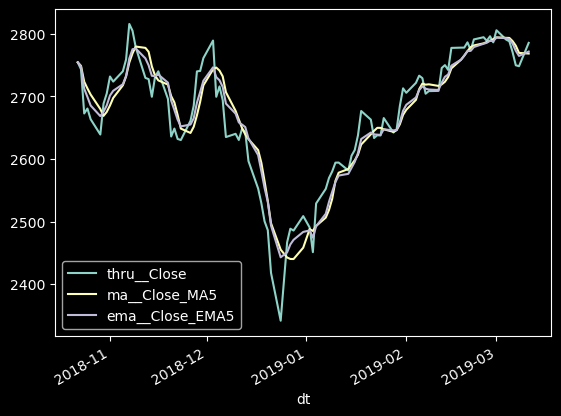

In [15]:
df_proc.loc[:, [c for c in df_proc.columns if 'Close' in c]].plot();

Create a dataset of original OHLCV data, the returns on Close and statistics on the returns.

First create a custom pipeline that returns its input as well as stats on its inputs.

In [16]:
pipe_stats = FeatureUnion([
    ('thru', 'passthrough'),
    ('std', StdTransformer(5)),
    ('ema5', EMATransformer(5)),
    ('ema20', EMATransformer(20)),
    ('ema60', EMATransformer(60))
    ])

pipe_stats

FeatureUnion(transformer_list=[('thru', 'passthrough'),
                               ('std', StdTransformer()),
                               ('ema5', EMATransformer()),
                               ('ema20', EMATransformer(window=20)),
                               ('ema60', EMATransformer(window=60))])

Then we create a pipeline to calculate the returns on Close and apply the stats pipeline to the returns.

In [17]:
pipe_returns = Pipeline([
    ('calc_returns', ReturnTransformer(1)),
    ('stats_returns', pipe_stats),
])
pipe_returns

Pipeline(steps=[('calc_returns', ReturnTransformer()),
                ('stats_returns',
                 FeatureUnion(transformer_list=[('thru', 'passthrough'),
                                                ('std', StdTransformer()),
                                                ('ema5', EMATransformer()),
                                                ('ema20',
                                                 EMATransformer(window=20)),
                                                ('ema60',
                                                 EMATransformer(window=60))]))])

This allows to create a dataset with the original OHLCV data, the returns on Close and statistics on the returns.

In [18]:
pipe = ColumnTransformer([
    ('thru', 'passthrough', ['Open', 'High', 'Low', 'Close', 'Volume']),
    ('ret', pipe_returns, ['Close']),
])

pipe

ColumnTransformer(transformers=[('thru', 'passthrough',
                                 ['Open', 'High', 'Low', 'Close', 'Volume']),
                                ('ret',
                                 Pipeline(steps=[('calc_returns',
                                                  ReturnTransformer()),
                                                 ('stats_returns',
                                                  FeatureUnion(transformer_list=[('thru',
                                                                                  'passthrough'),
                                                                                 ('std',
                                                                                  StdTransformer()),
                                                                                 ('ema5',
                                                                                  EMATransformer()),
                                                                                 ('ema20',
                                                                                  EMATransformer(window=20)),
                                                                                 ('ema60',
                                                                                  EMATransformer(window=60))]))]),
                                 ['Close'])])

In [19]:
df_proc = pd.DataFrame(
    data=pipe.fit_transform(df), 
    columns=pipe.get_feature_names_out(),
    index=df.index)
df_proc.head(5)

,thru__Open,thru__High,thru__Low,thru__Close,thru__Volume,ret__thru__Close_ret1,ret__std__Close_ret1_std5,ret__ema5__Close_ret1_EMA5,ret__ema20__Close_ret1_EMA20,ret__ema60__Close_ret1_EMA60
dt,,,,,,,,,,
2018-10-22,2759.02,2779.27,2747.27,2754.48,26562.0,0.000000,NaN,0.000000,0.000000,0.000000
2018-10-23,2753.11,2755.36,2690.69,2743.45,38777.0,-0.004004,0.002832,-0.002403,-0.002102,-0.002036
2018-10-24,2744.83,2748.58,2651.23,2672.80,41777.0,-0.025752,0.013858,-0.013463,-0.010786,-0.010206
2018-10-25,2670.80,2722.90,2657.93,2680.71,39034.0,0.002959,0.013019,-0.006641,-0.006818,-0.006748
2018-10-26,2675.59,2692.34,2627.59,2663.57,61436.0,-0.006394,0.011275,-0.006546,-0.006716,-0.006673


The pipeline generates a pretty long name for the features.

We can use `simplify_colnames` to simplify the names of the features.

In [20]:
df_proc = pd.DataFrame(
    data=pipe.fit_transform(df), 
    columns=simplify_colnames(pipe.get_feature_names_out()),
    index=df.index)
df_proc.head(5)

,Open,High,Low,Close,Volume,Close_ret1,Close_ret1_std5,Close_ret1_EMA5,Close_ret1_EMA20,Close_ret1_EMA60
dt,,,,,,,,,,
2018-10-22,2759.02,2779.27,2747.27,2754.48,26562.0,0.000000,NaN,0.000000,0.000000,0.000000
2018-10-23,2753.11,2755.36,2690.69,2743.45,38777.0,-0.004004,0.002832,-0.002403,-0.002102,-0.002036
2018-10-24,2744.83,2748.58,2651.23,2672.80,41777.0,-0.025752,0.013858,-0.013463,-0.010786,-0.010206
2018-10-25,2670.80,2722.90,2657.93,2680.71,39034.0,0.002959,0.013019,-0.006641,-0.006818,-0.006748
2018-10-26,2675.59,2692.34,2627.59,2663.57,61436.0,-0.006394,0.011275,-0.006546,-0.006716,-0.006673


`dframe` performs this operation on the dataframe directly

In [21]:
dframe(df, pipe).head(5)

,Open,High,Low,Close,Volume,Close_ret1,Close_ret1_std5,Close_ret1_EMA5,Close_ret1_EMA20,Close_ret1_EMA60
dt,,,,,,,,,,
2018-10-22,2759.02,2779.27,2747.27,2754.48,26562.0,0.000000,NaN,0.000000,0.000000,0.000000
2018-10-23,2753.11,2755.36,2690.69,2743.45,38777.0,-0.004004,0.002832,-0.002403,-0.002102,-0.002036
2018-10-24,2744.83,2748.58,2651.23,2672.80,41777.0,-0.025752,0.013858,-0.013463,-0.010786,-0.010206
2018-10-25,2670.80,2722.90,2657.93,2680.71,39034.0,0.002959,0.013019,-0.006641,-0.006818,-0.006748
2018-10-26,2675.59,2692.34,2627.59,2663.57,61436.0,-0.006394,0.011275,-0.006546,-0.006716,-0.006673


## Complex pipeline

In [25]:
from myquantlab.pipeline import build_pipeline

In [26]:
coi = 'Open Close'.split(' ')
transforms = [ReturnTransformer(1), ReturnTransformer(10)]
stats = [EMATransformer(5), EMATransformer(20), EMATransformer(60), StdTransformer(5)]

In [27]:
show_doc(build_pipeline)

---

[source](https://github.com/vtecftwy/myquantlab/blob/main/myquantlab/pipeline.py#LNone){target="_blank" style="float:right; font-size:smaller"}

### build_pipeline

>      build_pipeline (coi, transforms, stats)

*Build a pipeline with the given transformers*

In [28]:
pipe = build_pipeline(coi, transforms, stats)
pipe

ColumnTransformer(transformers=[('thru', 'passthrough',
                                 ['Open', 'High', 'Low', 'Close', 'Volume']),
                                ('return1',
                                 Pipeline(steps=[('return1',
                                                  ReturnTransformer()),
                                                 ('return1stats',
                                                  FeatureUnion(transformer_list=[('thru',
                                                                                  'passthrough'),
                                                                                 ('ema5',
                                                                                  EMATransformer()),
                                                                                 ('ema20',
                                                                                  EMATransformer(window=20)),
                                                                                 ('ema60',
                                                                                  EMATransformer(window=60)),
                                                                                 ('std5',
                                                                                  StdTransformer())]))]),
                                 ['Open', 'Close']),
                                ('return10',
                                 Pipeline(steps=[('return10',
                                                  ReturnTransformer(periods=10)),
                                                 ('return10stats',
                                                  FeatureUnion(transformer_list=[('thru',
                                                                                  'passthrough'),
                                                                                 ('ema5',
                                                                                  EMATransformer()),
                                                                                 ('ema20',
                                                                                  EMATransformer(window=20)),
                                                                                 ('ema60',
                                                                                  EMATransformer(window=60)),
                                                                                 ('std5',
                                                                                  StdTransformer())]))]),
                                 ['Open', 'Close'])])

In [29]:
dframe(df, pipe).head(5)

,Open,High,Low,Close,Volume,Open_ret1,Close_ret1,Open_ret1_EMA5,Close_ret1_EMA5,Open_ret1_EMA20,...,Open_ret10,Close_ret10,Open_ret10_EMA5,Close_ret10_EMA5,Open_ret10_EMA20,Close_ret10_EMA20,Open_ret10_EMA60,Close_ret10_EMA60,Open_ret10_std5,Close_ret10_std5
dt,,,,,,,,,,,,,,,,,,,,,
2018-10-22,2759.02,2779.27,2747.27,2754.48,26562.0,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN
2018-10-23,2753.11,2755.36,2690.69,2743.45,38777.0,-0.002142,-0.004004,-0.001285,-0.002403,-0.001125,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2018-10-24,2744.83,2748.58,2651.23,2672.80,41777.0,-0.003008,-0.025752,-0.002101,-0.013463,-0.001816,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2018-10-25,2670.80,2722.90,2657.93,2680.71,39034.0,-0.026971,0.002959,-0.012432,-0.006641,-0.009078,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2018-10-26,2675.59,2692.34,2627.59,2663.57,61436.0,0.001793,-0.006394,-0.006971,-0.006546,-0.006448,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
